In [1]:
import os, warnings, logging, sys, io

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
warnings.filterwarnings('ignore')
logging.getLogger('tensorflow').setLevel(logging.ERROR)

_stderr = sys.stderr
sys.stderr = io.StringIO()

import numpy as np
import tensorflow as tf
import keras                    # ← Import Keras separately

sys.stderr = _stderr

import matplotlib.pyplot as plt

IMG_HEIGHT = 224
IMG_WIDTH  = 224
BATCH_SIZE = 32
DATA_DIR   = r"flower_images"

In [2]:
# Cell 2 - Load data
train_dataset = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR, validation_split=0.2, subset="training",
    seed=42, image_size=(IMG_HEIGHT, IMG_WIDTH), batch_size=BATCH_SIZE
)
val_dataset = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR, validation_split=0.2, subset="validation",
    seed=42, image_size=(IMG_HEIGHT, IMG_WIDTH), batch_size=BATCH_SIZE
)
class_names = train_dataset.class_names
print("Flower classes:", class_names)

Found 3670 files belonging to 5 classes.
Using 2936 files for training.
Found 3670 files belonging to 5 classes.
Using 734 files for validation.
Flower classes: ['daisy_images', 'dandelion_images', 'rose_images', 'sunflower_images', 'tulip_images']


In [3]:
# Cell 3 - Performance
AUTOTUNE = tf.data.AUTOTUNE
train_dataset = train_dataset.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_dataset   = val_dataset.cache().prefetch(buffer_size=AUTOTUNE)

In [4]:
# Cell 4 - Augmentation
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.15),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomContrast(0.1),
], name="data_augmentation")

In [5]:
# Cell 5 - Model
model = tf.keras.Sequential([
    data_augmentation,
    tf.keras.layers.Rescaling(1./255),

    tf.keras.layers.Conv2D(32,  (3,3), activation='relu', padding='same'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Conv2D(64,  (3,3), activation='relu', padding='same'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Conv2D(256, (3,3), activation='relu', padding='same'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dropout(0.4),
    tf.keras.layers.Dense(5)
])

model.build((None, IMG_HEIGHT, IMG_WIDTH, 3))
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 data_augmentation (Sequent  (None, 224, 224, 3)       0         
 ial)                                                            
                                                                 
 rescaling (Rescaling)       (None, 224, 224, 3)       0         
                                                                 
 conv2d (Conv2D)             (None, 224, 224, 32)      896       
                                                                 
 batch_normalization (Batch  (None, 224, 224, 32)      128       
 Normalization)                                                  
                                                                 
 max_pooling2d (MaxPooling2  (None, 112, 112, 32)      0         
 D)                                                              
                                                        

In [6]:
# Cell 6 - Compile & Train
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=5,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-6
    )
]

history = model.fit(
    train_dataset, validation_data=val_dataset,
    epochs=20, callbacks=callbacks
)

Epoch 1/20
92/92 [==============================] - 251s 3s/step - loss: 1.2842 - accuracy: 0.5129 - val_loss: 1.7999 - val_accuracy: 0.2520 - lr: 0.0010
Epoch 2/20
92/92 [==============================] - 288s 3s/step - loss: 1.0636 - accuracy: 0.5865 - val_loss: 2.3374 - val_accuracy: 0.2602 - lr: 0.0010
Epoch 3/20
92/92 [==============================] - 279s 3s/step - loss: 1.0188 - accuracy: 0.5957 - val_loss: 1.7701 - val_accuracy: 0.2997 - lr: 0.0010
Epoch 4/20
92/92 [==============================] - 287s 3s/step - loss: 0.9511 - accuracy: 0.6247 - val_loss: 2.3743 - val_accuracy: 0.2902 - lr: 0.0010
Epoch 5/20
92/92 [==============================] - 193s 2s/step - loss: 0.8848 - accuracy: 0.6611 - val_loss: 1.5003 - val_accuracy: 0.4373 - lr: 0.0010
Epoch 6/20
92/92 [==============================] - 192s 2s/step - loss: 0.8608 - accuracy: 0.6655 - val_loss: 0.9993 - val_accuracy: 0.5858 - lr: 0.0010
Epoch 7/20
92/92 [==============================] - 192s 2s/step - loss: 0.8

Final train accuracy : 80.65%
Final val accuracy   : 77.52%


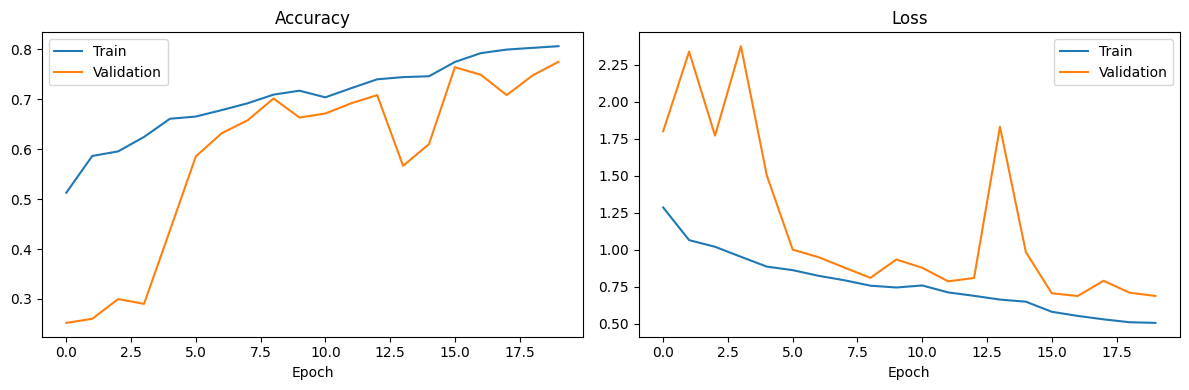

In [7]:
# Cell 7 - Results
print(f"Final train accuracy : {history.history['accuracy'][-1]:.2%}")
print(f"Final val accuracy   : {history.history['val_accuracy'][-1]:.2%}")

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'],     label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title("Accuracy"); plt.xlabel("Epoch"); plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'],     label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title("Loss"); plt.xlabel("Epoch"); plt.legend()
plt.tight_layout(); plt.show()

model.save('cnn_model.keras')

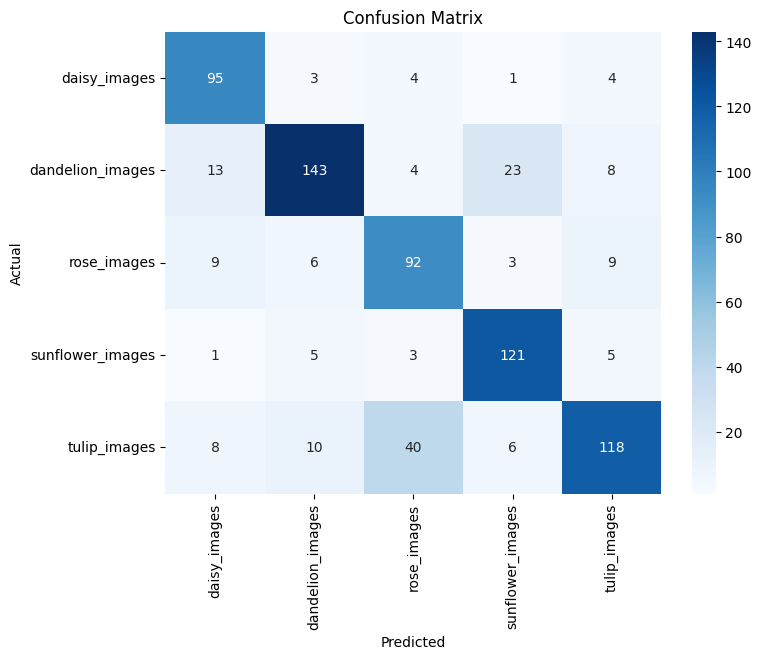

                  precision    recall  f1-score   support

    daisy_images       0.75      0.89      0.82       107
dandelion_images       0.86      0.75      0.80       191
     rose_images       0.64      0.77      0.70       119
sunflower_images       0.79      0.90      0.84       135
    tulip_images       0.82      0.65      0.72       182

        accuracy                           0.78       734
       macro avg       0.77      0.79      0.78       734
    weighted avg       0.78      0.78      0.77       734



In [9]:
model = tf.keras.models.load_model("cnn_model.keras")
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
y_true = []
y_pred = []
for images, labels in val_dataset:
    preds = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()
print(classification_report(y_true, y_pred, target_names=class_names))